# Visualising Tensors → Single-Head Attention

A visual walkthrough of tensors in PyTorch, growing in complexity from a scalar to the full **Single-Head Attention** mechanism.

| Step | Tensor Shape | Concept |
|------|-------------|---------|
| 1 | `()` | Scalar |
| 2 | `(d,)` | Vector / token embedding |
| 3 | `(T, d)` | Sequence of embeddings |
| 4 | `(T, d)` | + Positional Encoding |
| 5 | `(T, d_k)` | Q, K, V projections |
| 6 | `(T, T)` | Attention scores (QKᵀ / √d_k) |
| 7 | `(T, T)` | Attention weights (softmax) |
| 8 | `(T, d_v)` | Output (weights × V) |

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

# ── Device selection: CUDA → MPS → CPU ─────────────────────────────────────────
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(f"Using device: {device}")

# ── shared helpers ──────────────────────────────────────────────────────────────

def show_tensor(t, title="", cmap="viridis", figsize=None, annot=True, fmt=".2f",
                xticklabels=None, yticklabels=None):
    """Generic heatmap for 1-D or 2-D tensors."""
    data = t.detach().cpu().float().numpy()   # .cpu() handles MPS/CUDA tensors
    if data.ndim == 1:
        data = data[np.newaxis, :]

    rows, cols = data.shape
    if figsize is None:
        figsize = (max(4, cols * 0.55), max(1.5, rows * 0.55))

    fig, ax = plt.subplots(figsize=figsize)
    im = ax.imshow(data, cmap=cmap, aspect="auto", vmin=data.min(), vmax=data.max())
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    if annot and rows * cols <= 200:
        for r in range(rows):
            for c in range(cols):
                ax.text(c, r, f"{data[r, c]:{fmt}}", ha="center", va="center",
                        fontsize=7, color="white" if abs(data[r, c]) > data.max() * 0.6 else "black")

    ax.set_xticks(range(cols))
    ax.set_xticklabels(xticklabels if xticklabels else range(cols), fontsize=8)
    ax.set_yticks(range(rows))
    ax.set_yticklabels(yticklabels if yticklabels else range(rows), fontsize=8)
    ax.set_title(title, fontsize=11, fontweight="bold")
    plt.tight_layout()
    plt.show()

torch.manual_seed(42)
print("PyTorch", torch.__version__, "  –  ready")

Using device: mps
PyTorch 2.6.0   –  ready


---
## Step 1 — Scalar  `shape: ()`

The simplest tensor: a single number. 0 dimensions, 0 axes. The building block of everything.

In [2]:
scalar = torch.tensor(3.14, device=device)
print(f"value  : {scalar.item():.4f}")
print(f"shape  : {scalar.shape}")      # torch.Size([])
print(f"ndim   : {scalar.ndim}")       # 0
print(f"device : {scalar.device}")

value  : 3.1400
shape  : torch.Size([])
ndim   : 0
device : mps:0


---
## Step 2 — Vector  `shape: (d,)`

A 1-D tensor. In transformer land this is what **one token's embedding** looks like — a list of `d` numbers that encode meaning.

Here `d = 8` (tiny; real models use `d = 512` or `d = 4096`).

shape  : torch.Size([8])   (one token embedding)
device : mps:0


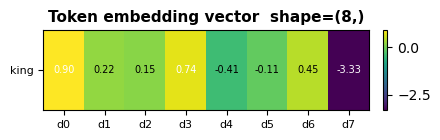

In [3]:
d_model = 8          # embedding dimension (kept tiny for readability)

token_vec = torch.randn(d_model, device=device)
print(f"shape  : {token_vec.shape}   (one token embedding)")
print(f"device : {token_vec.device}")

show_tensor(token_vec,
            title=f'Token embedding vector  shape=({d_model},)',
            xticklabels=[f"d{i}" for i in range(d_model)],
            yticklabels=["king"])

---
## Step 3 — Matrix  `shape: (T, d)`

Stack `T` token vectors → a 2-D matrix.  
This is the **input sequence**: `T` tokens, each with `d` features.

Sentence: `"The king rules"` → T = 3 tokens

shape  : torch.Size([3, 8])   (T=3 tokens × d=8 dims)
device : mps:0


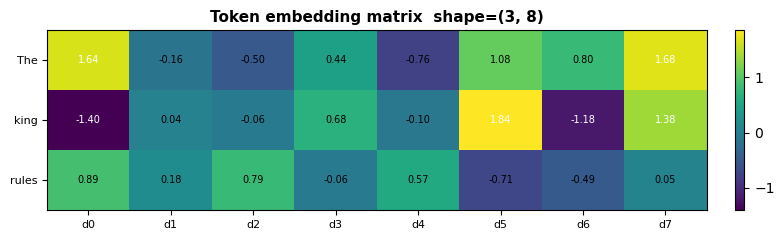

In [4]:
tokens = ["The", "king", "rules"]
T = len(tokens)

vocab_size = 100
embedding = nn.Embedding(vocab_size, d_model).to(device)

token_ids = torch.tensor([2, 7, 42], device=device)
X_embed = embedding(token_ids)                 # shape: (T, d_model)

print(f"shape  : {X_embed.shape}   (T={T} tokens × d={d_model} dims)")
print(f"device : {X_embed.device}")

show_tensor(X_embed.detach(),
            title=f"Token embedding matrix  shape=({T}, {d_model})",
            xticklabels=[f"d{i}" for i in range(d_model)],
            yticklabels=tokens,
            figsize=(8, 2.5))

---
## Step 4 — Positional Encoding  `shape: (T, d)`

Embeddings have no concept of order — "king rules the" and "the rules king" produce identical matrices.  
We **add** a positional signal so the model knows token position.

**Formula** (Vaswani et al. 2017):

$$PE_{(pos,\,2i)} = \sin\!\left(\frac{pos}{10000^{2i/d}}\right) \qquad PE_{(pos,\,2i+1)} = \cos\!\left(\frac{pos}{10000^{2i/d}}\right)$$

The result is still `(T, d)` — same shape, richer content.

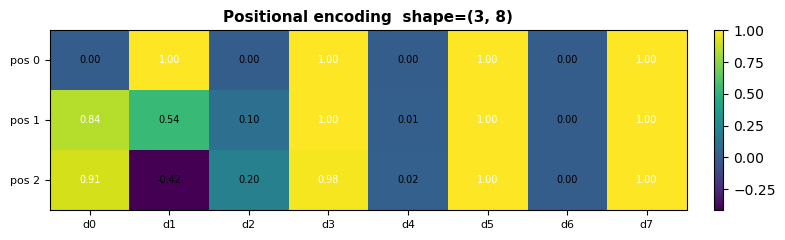

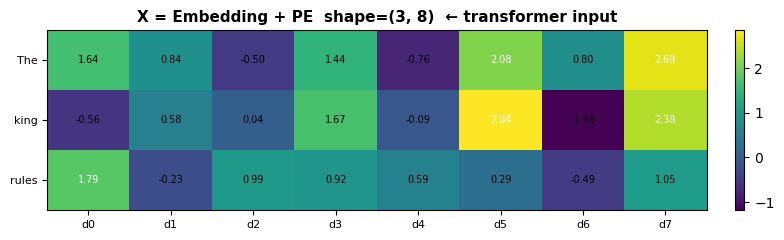

In [5]:
def positional_encoding(T, d, device):
    """Returns PE tensor of shape (T, d) on the given device."""
    pe = torch.zeros(T, d, device=device)
    pos = torch.arange(T, device=device).unsqueeze(1)
    div = torch.exp(torch.arange(0, d, 2, device=device) * (-np.log(10000.0) / d))
    pe[:, 0::2] = torch.sin(pos * div)
    pe[:, 1::2] = torch.cos(pos * div[:d//2])
    return pe

PE = positional_encoding(T, d_model, device)

show_tensor(PE,
            title=f"Positional encoding  shape=({T}, {d_model})",
            xticklabels=[f"d{i}" for i in range(d_model)],
            yticklabels=[f"pos {i}" for i in range(T)],
            figsize=(8, 2.5))

X = X_embed.detach() + PE

show_tensor(X,
            title=f"X = Embedding + PE  shape=({T}, {d_model})  ← transformer input",
            xticklabels=[f"d{i}" for i in range(d_model)],
            yticklabels=tokens,
            figsize=(8, 2.5))

---
## Step 5 — Q, K, V Projections  `shape: (T, d_k)`

The input `X` is linearly projected into **three separate spaces** via learned weight matrices:

| Projection | Weight shape | Output shape | Role |
|-----------|-------------|-------------|------|
| **Q** (Query) | `(d, d_k)` | `(T, d_k)` | "What am I looking for?" |
| **K** (Key)   | `(d, d_k)` | `(T, d_k)` | "What do I contain?" |
| **V** (Value) | `(d, d_v)` | `(T, d_v)` | "What do I return if matched?" |

Typically `d_k = d_v = d_model / num_heads`. Here we use `d_k = d_v = 4`.

Q shape: torch.Size([3, 4])  device: mps:0
K shape: torch.Size([3, 4])  device: mps:0
V shape: torch.Size([3, 4])  device: mps:0


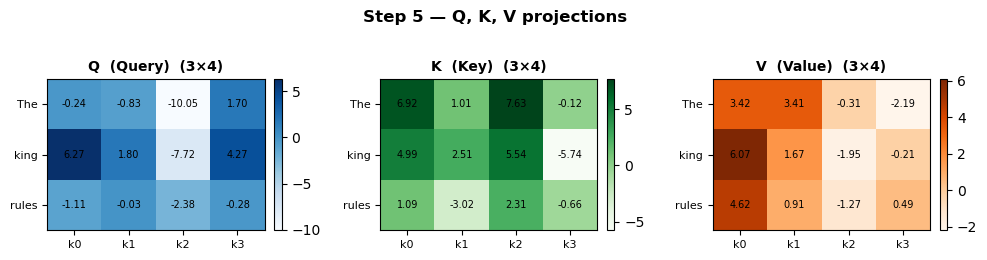

In [6]:
d_k = 4   # key/query dimension
d_v = 4   # value dimension

W_Q = torch.randn(d_model, d_k, device=device)
W_K = torch.randn(d_model, d_k, device=device)
W_V = torch.randn(d_model, d_v, device=device)

Q = X @ W_Q   # (T, d_k)
K = X @ W_K   # (T, d_k)
V = X @ W_V   # (T, d_v)

print(f"Q shape: {Q.shape}  device: {Q.device}")
print(f"K shape: {K.shape}  device: {K.device}")
print(f"V shape: {V.shape}  device: {V.device}")

fig, axes = plt.subplots(1, 3, figsize=(10, 2.5))
for ax, mat, name, cmap in zip(axes, [Q, K, V], ["Q  (Query)", "K  (Key)", "V  (Value)"],
                                ["Blues", "Greens", "Oranges"]):
    data = mat.detach().cpu().numpy()
    im = ax.imshow(data, cmap=cmap, aspect="auto")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    for r in range(data.shape[0]):
        for c in range(data.shape[1]):
            ax.text(c, r, f"{data[r,c]:.2f}", ha="center", va="center", fontsize=7)
    ax.set_xticks(range(d_k))
    ax.set_xticklabels([f"k{i}" for i in range(d_k)], fontsize=8)
    ax.set_yticks(range(T))
    ax.set_yticklabels(tokens, fontsize=8)
    ax.set_title(f"{name}  ({T}×{d_k})", fontsize=10, fontweight="bold")
plt.suptitle("Step 5 — Q, K, V projections", fontsize=12, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

---
## Step 6 — Attention Scores  `shape: (T, T)`

$$\text{Scores} = \frac{QK^\top}{\sqrt{d_k}}$$

- `Q @ K.T` → each row is a query token, each column is a key token  
- Cell `[i, j]` = "how much should token `i` attend to token `j`?"  
- Dividing by `√d_k` prevents dot products from exploding in magnitude (stabilises softmax gradients)

Scores shape: torch.Size([3, 3])


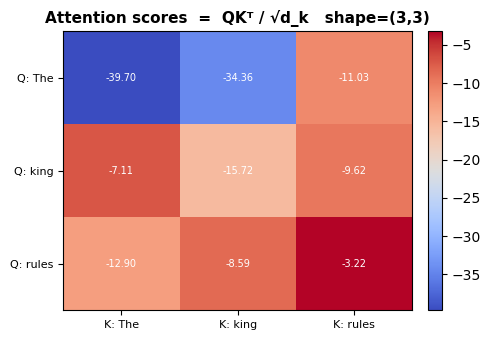

Row  = query token (what it's asking)
Col  = key token   (what it's comparing against)


In [7]:
scores = Q @ K.T / (d_k ** 0.5)    # (T, T)
print(f"Scores shape: {scores.shape}")

show_tensor(scores.detach(),
            title=f"Attention scores  =  QKᵀ / √d_k   shape=({T},{T})",
            cmap="coolwarm",
            xticklabels=[f"K: {t}" for t in tokens],
            yticklabels=[f"Q: {t}" for t in tokens],
            figsize=(5, 3.5))

print("Row  = query token (what it's asking)")
print("Col  = key token   (what it's comparing against)")

---
## Step 7 — Attention Weights  `shape: (T, T)`

Apply **softmax** row-wise so each row sums to 1.  
Now every cell is a proper probability: "token `i` distributes 100% of its attention across all positions."

$$\text{Weights} = \text{softmax}\!\left(\frac{QK^\top}{\sqrt{d_k}}\right)$$

> **Causal masking** (used in decoders): mask future positions to `-inf` before softmax so token `i` can only attend to positions `≤ i`.

Attention weights shape: torch.Size([3, 3])  device: mps:0
Row sums (should all be 1.0): [1.        0.9999999 1.0000001]


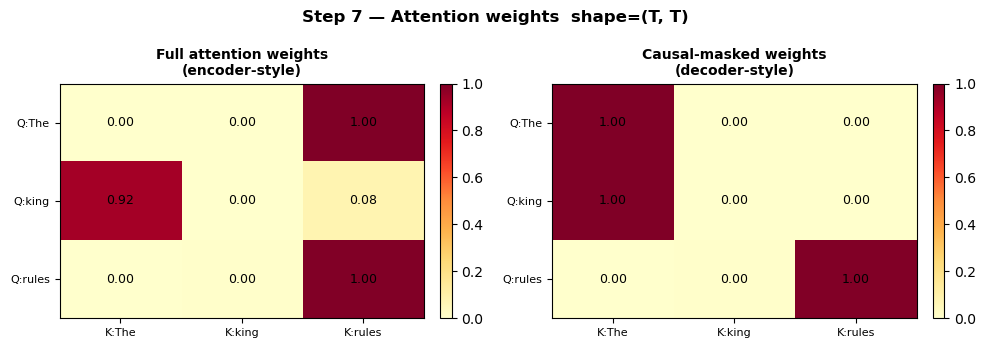

In [8]:
attn_weights = F.softmax(scores, dim=-1)

causal_mask = torch.triu(torch.ones(T, T, device=device), diagonal=1).bool()
masked_scores = scores.masked_fill(causal_mask, float('-inf'))
causal_weights = F.softmax(masked_scores, dim=-1)

print(f"Attention weights shape: {attn_weights.shape}  device: {attn_weights.device}")
print(f"Row sums (should all be 1.0): {attn_weights.sum(dim=-1).detach().cpu().numpy()}")

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
for ax, w, title in zip(axes,
                         [attn_weights, causal_weights],
                         ["Full attention weights\n(encoder-style)", "Causal-masked weights\n(decoder-style)"]):
    data = w.detach().cpu().numpy()
    im = ax.imshow(data, cmap="YlOrRd", vmin=0, vmax=1, aspect="auto")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    for r in range(T):
        for c in range(T):
            ax.text(c, r, f"{data[r,c]:.2f}", ha="center", va="center", fontsize=9)
    ax.set_xticks(range(T)); ax.set_xticklabels([f"K:{t}" for t in tokens], fontsize=8)
    ax.set_yticks(range(T)); ax.set_yticklabels([f"Q:{t}" for t in tokens], fontsize=8)
    ax.set_title(title, fontsize=10, fontweight="bold")
plt.suptitle("Step 7 — Attention weights  shape=(T, T)", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

---
## Step 8 — Attention Output  `shape: (T, d_v)`

Multiply attention weights by V — each output token is a **weighted sum of Value vectors**.

$$\text{Output} = \text{Weights} \cdot V$$

| Tensor | Shape | Meaning |
|--------|-------|---------|
| Weights | `(T, T)` | how much each query attends to each key |
| V | `(T, d_v)` | value content at each position |
| **Output** | `(T, d_v)` | context-enriched representation |

This is the complete **Scaled Dot-Product Attention** formula:

$$\text{Attention}(Q,K,V) = \text{softmax}\!\left(\frac{QK^\top}{\sqrt{d_k}}\right)V$$

Output shape: torch.Size([3, 4])  device: mps:0


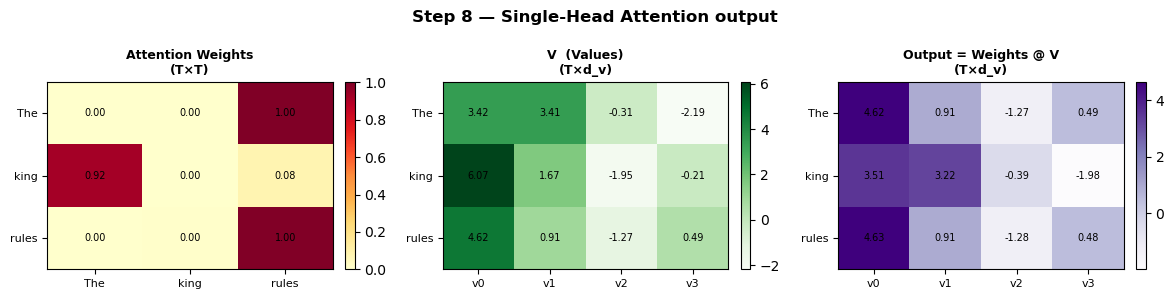

In [9]:
output = attn_weights @ V   # (T, d_v)
print(f"Output shape: {output.shape}  device: {output.device}")

fig, axes = plt.subplots(1, 3, figsize=(12, 3))
panels = [
    (attn_weights.detach(), "Attention Weights\n(T×T)",      "YlOrRd",  tokens,                        tokens),
    (V.detach(),            "V  (Values)\n(T×d_v)",          "Greens",  [f"v{i}" for i in range(d_v)], tokens),
    (output.detach(),       "Output = Weights @ V\n(T×d_v)", "Purples", [f"v{i}" for i in range(d_v)], tokens),
]
for ax, (data_t, panel_title, cmap, xlabels, ylabels) in zip(axes, panels):
    data = data_t.cpu().numpy()
    im = ax.imshow(data, cmap=cmap, aspect="auto")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    for r in range(data.shape[0]):
        for c in range(data.shape[1]):
            ax.text(c, r, f"{data[r,c]:.2f}", ha="center", va="center", fontsize=7)
    ax.set_xticks(range(data.shape[1])); ax.set_xticklabels(xlabels, fontsize=8)
    ax.set_yticks(range(data.shape[0])); ax.set_yticklabels(ylabels, fontsize=8)
    ax.set_title(panel_title, fontsize=9, fontweight="bold")

plt.suptitle("Step 8 — Single-Head Attention output", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

---
## Full Pipeline Summary

```
token_ids  (T,)
    │
    ▼  nn.Embedding
X_embed    (T, d)
    │
    +  Positional Encoding (T, d)
    │
    ▼
X          (T, d)   ← transformer input
    │
    ├──@W_Q──▶  Q  (T, d_k)
    ├──@W_K──▶  K  (T, d_k)
    └──@W_V──▶  V  (T, d_v)
                │
                ▼  Q @ Kᵀ / √d_k
           Scores    (T, T)
                │
                ▼  softmax(dim=-1)
           Weights   (T, T)
                │
                ▼  @ V
           Output    (T, d_v)   ← context-enriched token representations
```

**What changed at each step:**

| Step | Shape | New info added |
|------|-------|---------------|
| Scalar | `()` | a number |
| Vector | `(d,)` | meaning of one token |
| Matrix | `(T, d)` | a full sequence |
| + PE | `(T, d)` | positional order |
| Q/K/V | `(T, d_k)` | three different "views" |
| Scores | `(T, T)` | pairwise token similarity |
| Weights | `(T, T)` | normalised attention distribution |
| **Output** | `(T, d_v)` | **context-aware representations** |


![8-step-headtmap-summary.png](8-step-headtmap-summary.png)

---
# Part 2 — Multi-Head Attention (3 Heads)

Instead of one set of Q/K/V projections, run **`num_heads` independent attention heads in parallel**, each learning to attend to different aspects of the sequence.

```
X  (T, d_model)
│
├─► Head 1: W_Q1, W_K1, W_V1  →  out_1  (T, d_head)  [syntax / grammar]
├─► Head 2: W_Q2, W_K2, W_V2  →  out_2  (T, d_head)  [semantics]
└─► Head 3: W_Q3, W_K3, W_V3  →  out_3  (T, d_head)  [positional / coreference]
                                      │
                              Concat  →  (T, num_heads × d_head)
                                      │
                              @ W_O   →  (T, d_model)   ← same shape as input
```

**Key numbers here:**
- `num_heads = 3`
- `d_head = 4`  (each head projects X from d_model=8 → 4 dims)
- Concatenated: `(T, 3×4)` = `(T, 12)`
- After output projection W_O `(12, 8)`: back to `(T, 8)` = `(T, d_model)`

---
## MHA Step 1 — Per-Head Q, K, V Projections  `shape: (T, d_head)` each

Each head has its **own independent weight matrices** — they learn completely different projections.

Per-head Q/K/V shape: torch.Size([3, 4])  (T=3 × d_head=4)


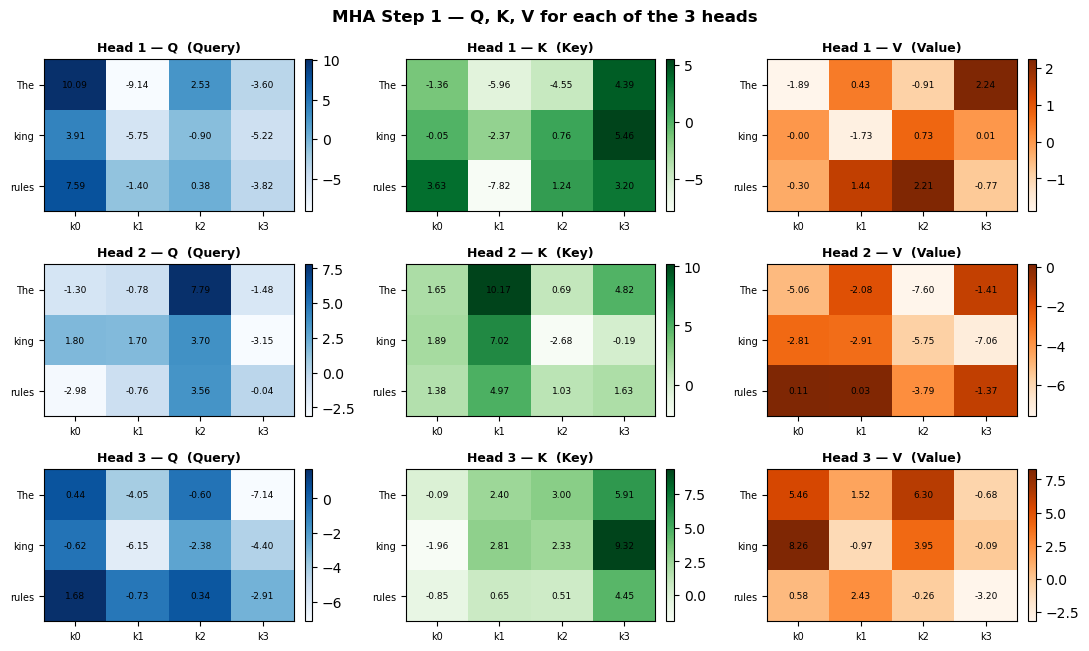

In [10]:
num_heads = 3
d_head    = 4   # each head's projection dim  (d_model=8 → d_head=4)

# One weight matrix per head per projection  shape: (d_model, d_head)
W_Qs = [torch.randn(d_model, d_head, device=device) for _ in range(num_heads)]
W_Ks = [torch.randn(d_model, d_head, device=device) for _ in range(num_heads)]
W_Vs = [torch.randn(d_model, d_head, device=device) for _ in range(num_heads)]

# Project X through each head
Qs = [X @ W_Qs[h] for h in range(num_heads)]   # each: (T, d_head)
Ks = [X @ W_Ks[h] for h in range(num_heads)]
Vs = [X @ W_Vs[h] for h in range(num_heads)]

print(f"Per-head Q/K/V shape: {Qs[0].shape}  (T={T} × d_head={d_head})")

# Visualise: rows = heads, cols = Q / K / V
fig, axes = plt.subplots(num_heads, 3, figsize=(11, num_heads * 2.2))
head_labels = [f"Head {h+1}" for h in range(num_heads)]
proj_labels = ["Q  (Query)", "K  (Key)", "V  (Value)"]
proj_cmaps  = ["Blues", "Greens", "Oranges"]

for h in range(num_heads):
    for p, (mat, pname, cmap) in enumerate(zip([Qs[h], Ks[h], Vs[h]], proj_labels, proj_cmaps)):
        ax = axes[h][p]
        data = mat.detach().cpu().numpy()
        im = ax.imshow(data, cmap=cmap, aspect="auto")
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        for r in range(data.shape[0]):
            for c in range(data.shape[1]):
                ax.text(c, r, f"{data[r,c]:.2f}", ha="center", va="center", fontsize=6.5)
        ax.set_xticks(range(d_head));  ax.set_xticklabels([f"k{i}" for i in range(d_head)], fontsize=7)
        ax.set_yticks(range(T));       ax.set_yticklabels(tokens, fontsize=7)
        ax.set_title(f"{head_labels[h]} — {pname}", fontsize=9, fontweight="bold")

plt.suptitle("MHA Step 1 — Q, K, V for each of the 3 heads", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

---
## MHA Step 2 — Per-Head Attention Weights  `shape: (T, T)` × 3

Each head computes its **own** `softmax(QKᵀ/√d_head)`.  
Notice how the three `(T×T)` maps differ — each head attends to the sequence differently.

Per-head attention weights shape: torch.Size([3, 3])


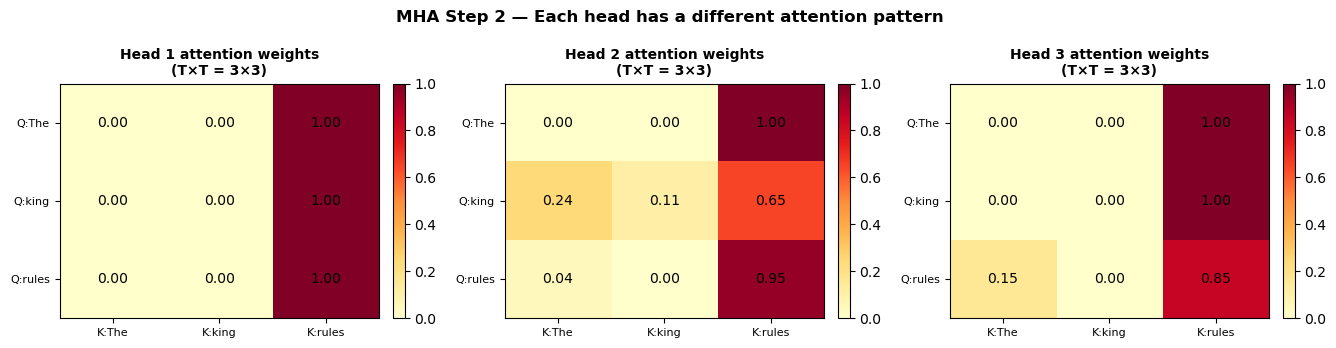

In [11]:
head_scores  = [Qs[h] @ Ks[h].T / (d_head ** 0.5) for h in range(num_heads)]   # (T, T) each
head_weights = [F.softmax(s, dim=-1) for s in head_scores]                       # (T, T) each

print(f"Per-head attention weights shape: {head_weights[0].shape}")

fig, axes = plt.subplots(1, num_heads, figsize=(4.5 * num_heads, 3.5))
for h, (ax, w) in enumerate(zip(axes, head_weights)):
    data = w.detach().cpu().numpy()
    im = ax.imshow(data, cmap="YlOrRd", vmin=0, vmax=1, aspect="auto")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    for r in range(T):
        for c in range(T):
            ax.text(c, r, f"{data[r,c]:.2f}", ha="center", va="center", fontsize=10)
    ax.set_xticks(range(T)); ax.set_xticklabels([f"K:{t}" for t in tokens], fontsize=8)
    ax.set_yticks(range(T)); ax.set_yticklabels([f"Q:{t}" for t in tokens], fontsize=8)
    ax.set_title(f"Head {h+1} attention weights\n(T×T = {T}×{T})", fontsize=10, fontweight="bold")

plt.suptitle("MHA Step 2 — Each head has a different attention pattern", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

---
## MHA Step 3 — Per-Head Outputs  `shape: (T, d_head)` × 3

Each head produces its own context-enriched output by computing `weights @ V`.

Per-head output shape: torch.Size([3, 4])


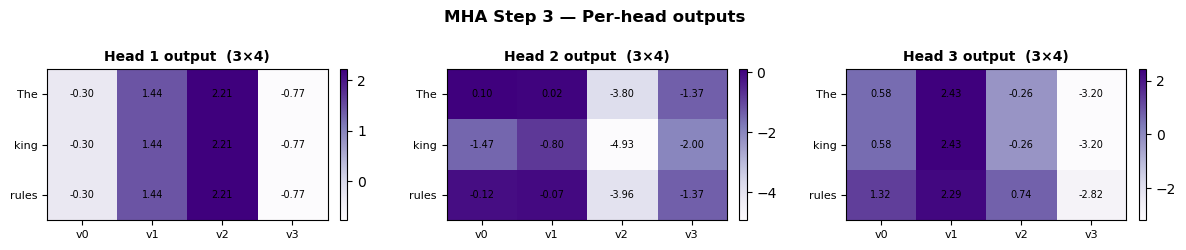

In [12]:
head_outputs = [head_weights[h] @ Vs[h] for h in range(num_heads)]   # each: (T, d_head)

print(f"Per-head output shape: {head_outputs[0].shape}")

fig, axes = plt.subplots(1, num_heads, figsize=(4 * num_heads, 2.5))
for h, (ax, out) in enumerate(zip(axes, head_outputs)):
    data = out.detach().cpu().numpy()
    im = ax.imshow(data, cmap="Purples", aspect="auto")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    for r in range(data.shape[0]):
        for c in range(data.shape[1]):
            ax.text(c, r, f"{data[r,c]:.2f}", ha="center", va="center", fontsize=7)
    ax.set_xticks(range(d_head)); ax.set_xticklabels([f"v{i}" for i in range(d_head)], fontsize=8)
    ax.set_yticks(range(T));      ax.set_yticklabels(tokens, fontsize=8)
    ax.set_title(f"Head {h+1} output  ({T}×{d_head})", fontsize=10, fontweight="bold")

plt.suptitle("MHA Step 3 — Per-head outputs", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

---
## MHA Step 4 — Concatenate + Output Projection

Stack the 3 head outputs side-by-side along the feature dimension:

```
[Head1_out | Head2_out | Head3_out]   →   (T, num_heads × d_head)  =  (T, 12)
```

Then multiply by **W_O** `(12, d_model=8)` to project back to the original model dimension — giving `(T, 8)`, the same shape as the input `X`.

Concatenated shape : torch.Size([3, 12])   (3 × 12)
W_O shape          : torch.Size([12, 8])       (12 → 8)
MHA output shape   : torch.Size([3, 8])    (3 × 8)  ← same as X input


ValueError: The number of FixedLocator locations (12), usually from a call to set_ticks, does not match the number of labels (8).

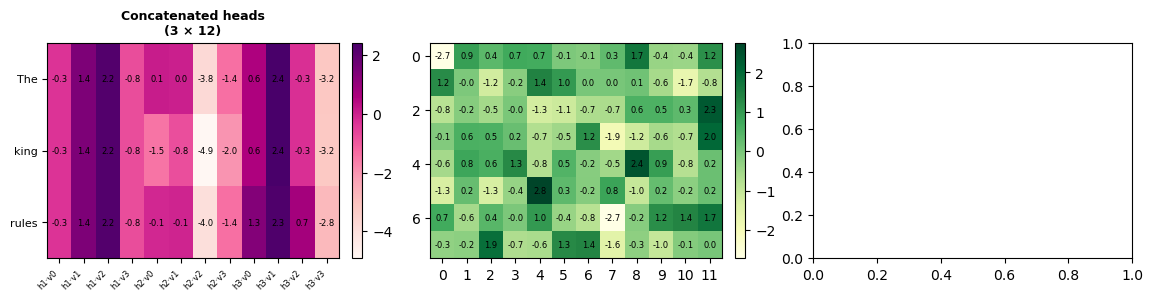

In [13]:
d_concat = num_heads * d_head   # 3 × 4 = 12

concat = torch.cat(head_outputs, dim=-1)          # (T, 12)
W_O    = torch.randn(d_concat, d_model, device=device)  # (12, 8)
mha_output = concat @ W_O                          # (T, 8)

print(f"Concatenated shape : {concat.shape}   ({T} × {d_concat})")
print(f"W_O shape          : {W_O.shape}       ({d_concat} → {d_model})")
print(f"MHA output shape   : {mha_output.shape}    ({T} × {d_model})  ← same as X input")

# Visualise the full flow: concat → W_O → output
fig, axes = plt.subplots(1, 3, figsize=(14, 2.8))

panels = [
    (concat,     f"Concatenated heads\n({T} × {d_concat})",  "RdPu",  [f"h{h//d_head+1}·v{h%d_head}" for h in range(d_concat)]),
    (W_O.T,      f"W_O  ({d_concat} → {d_model})\nshown transposed", "YlGn",  [f"d{i}" for i in range(d_model)]),
    (mha_output, f"MHA output\n({T} × {d_model})",            "plasma", [f"d{i}" for i in range(d_model)]),
]

for ax, (tensor, panel_title, cmap, xlabels) in zip(axes, panels):
    data = tensor.detach().cpu().numpy()
    im = ax.imshow(data, cmap=cmap, aspect="auto")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    for r in range(data.shape[0]):
        for c in range(data.shape[1]):
            ax.text(c, r, f"{data[r,c]:.1f}", ha="center", va="center", fontsize=6)
    ax.set_xticks(range(data.shape[1])); ax.set_xticklabels(xlabels, fontsize=6, rotation=45, ha="right")
    ax.set_yticks(range(data.shape[0])); ax.set_yticklabels(tokens if data.shape[0] == T else [f"d{i}" for i in range(data.shape[0])], fontsize=8)
    ax.set_title(panel_title, fontsize=9, fontweight="bold")

plt.suptitle("MHA Step 4 — Concat  →  W_O  →  Final Output", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

---
## Single-Head vs Multi-Head — Side-by-Side Comparison

| | Single-Head | Multi-Head (3 heads) |
|---|---|---|
| Q/K/V projections | 1 set | 3 independent sets |
| Attention map | 1 × `(T, T)` | 3 × `(T, T)` |
| Head output | `(T, d_v=4)` | 3 × `(T, d_head=4)` |
| After concat | — | `(T, 12)` |
| After W_O | `(T, 4)` | `(T, 8)` = `(T, d_model)` |
| What it learns | one attention pattern | three diverse patterns in parallel |

**Why multi-head?**  
Each head can specialise — one might learn syntactic dependencies, another long-range coreference, another local context. The concatenation + W_O lets the model combine all of them.

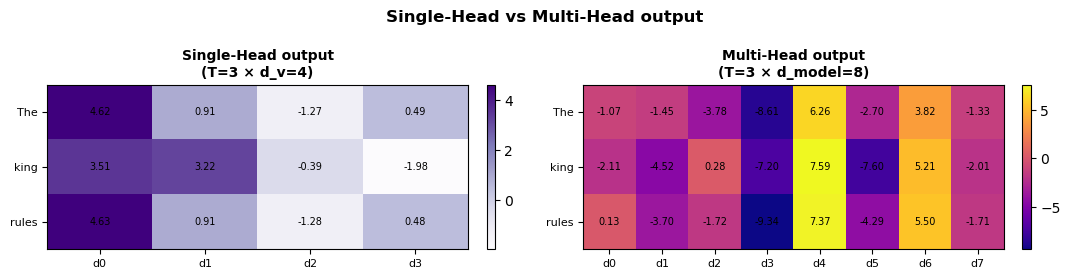

In [14]:
# ── Single-head output (from Part 1) vs MHA output — shape comparison ───────────
fig, axes = plt.subplots(1, 2, figsize=(11, 2.8))

for ax, (tensor, panel_title, cmap) in zip(axes, [
    (output,     f"Single-Head output\n(T={T} × d_v={d_v})",     "Purples"),
    (mha_output, f"Multi-Head output\n(T={T} × d_model={d_model})", "plasma"),
]):
    data = tensor.detach().cpu().numpy()
    im = ax.imshow(data, cmap=cmap, aspect="auto")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    for r in range(data.shape[0]):
        for c in range(data.shape[1]):
            ax.text(c, r, f"{data[r,c]:.2f}", ha="center", va="center", fontsize=7)
    ax.set_xticks(range(data.shape[1])); ax.set_xticklabels([f"d{i}" for i in range(data.shape[1])], fontsize=8)
    ax.set_yticks(range(T));             ax.set_yticklabels(tokens, fontsize=8)
    ax.set_title(panel_title, fontsize=10, fontweight="bold")

plt.suptitle("Single-Head vs Multi-Head output", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()